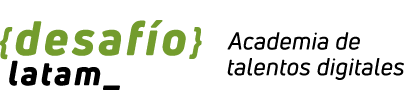

# <center><font color='green'>Regresión logística</font></center>

Veremos ahora cómo implementar un modelo de regresión logística para una base de datos, buscando relacionar algunas características de pacientes con su diagnóstico.

Para esto, cargaremos las bibliotecas necesarias y la data.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('breast cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [18]:
df['diagnosis'].value_counts('%')

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

Preparamos los datos. Para ello podríamos hacer un análisis exploratorio de los mismos, en n uestro caso solo eliminaremos una columna con valores nulos.

In [21]:
df.drop(['Unnamed: 32', 'id'], axis=1, inplace=True)

In [23]:
variables = df.columns
print(variables)

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

## <font color='green'>Nuestro modelo de regresión</font>

Vamos a escoger algunas variables de nuestra base de datos y aplicaremos el modelo de regresión logística.

In [28]:
# Variables
X = df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']]
y = df['diagnosis'].map({'M': 1, 'B': 0})

# 1. División de datos (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# 2. Ajuste del modelo con datos de entrenamiento
model = LogisticRegression()
model.fit(X_train, y_train) #70%

# 3. Predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test) # modelo listo y hago predicción sobre el 30% test

# 4. Evaluación con etiquetas reales de prueba (y_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy}')

print('Matriz de Confusión:')
print(confusion_matrix(y_test, y_pred))

print('Informe de Clasificación:')
print(classification_report(y_test, y_pred))

Precisión del modelo: 0.935672514619883
Matriz de Confusión:
[[101   7]
 [  4  59]]
Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       108
           1       0.89      0.94      0.91        63

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.93       171
weighted avg       0.94      0.94      0.94       171



## <font color='green'>Evaluando el modelo</font>

Calcularemos ahora las métricas de evaluación para nuestro modelo.

AUC-ROC: 0.972398393319592
AUC-PR: 0.9613160333992783


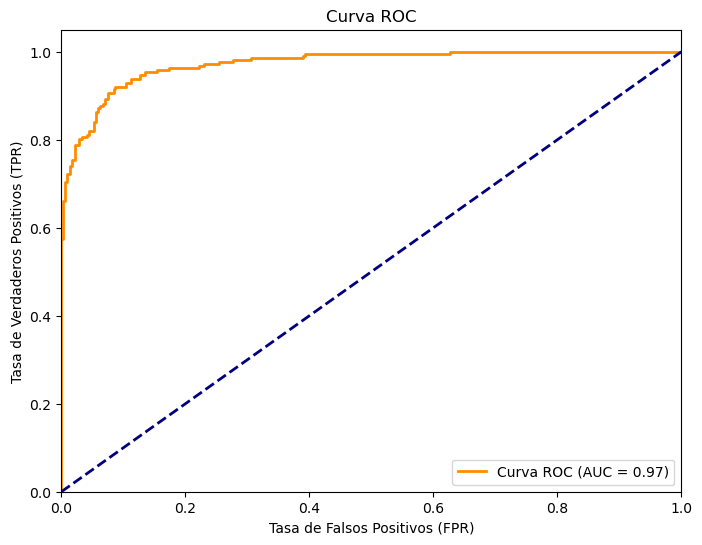

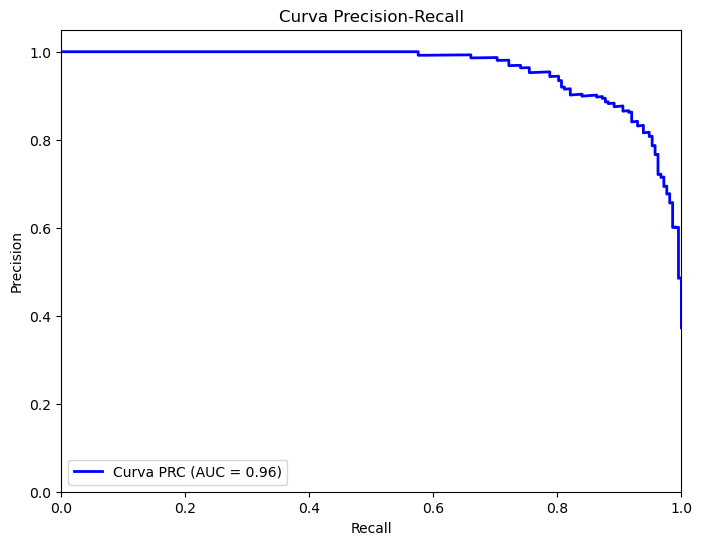

In [32]:
# Obtener las probabilidades de predicción
y_prob = model.predict_proba(X)[:, 1]

# Calcular el AUC-ROC
roc_auc = roc_auc_score(y, y_prob)
print(f'AUC-ROC: {roc_auc}')

# Calcular el AUC-PR
prc_auc = average_precision_score(y, y_prob)
print(f'AUC-PR: {prc_auc}')

# Calcular la curva ROC
fpr, tpr, thresholds_roc = roc_curve(y, y_prob)

# Calcular la curva PRC
precision, recall, thresholds_prc = precision_recall_curve(y, y_prob)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')

# Graficar la curva PRC
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label='Curva PRC (AUC = %0.2f)' % prc_auc)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(loc='lower left')

# Mostrar las curvas ROC y PRC
plt.show()

In [34]:
# Obtener las probabilidades predichas
y_proba_mal = model.predict_proba(X)[:, 1]  # Probabilidad de la clase "maligno" (1)
y_proba_ben = model.predict_proba(X)[:, 0]  # Probabilidad de la clase "benigno" (0)

# Agregar las probabilidades al DataFrame X
X['Probabilidad Maligno'] = y_proba_mal
X['Probabilidad benigno'] = y_proba_ben

# Agregar las etiquetas predichas 'y_pred' al DataFrame X
X['Predicción'] = y_pred

# Agregar las etiquetas originales 'y' al DataFrame X
X['Diagnóstico Original'] = y.values

# Mostrar las primeras filas del DataFrame actualizado
X.head(100)



,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,Probabilidad Maligno,Probabilidad benigno,Predicción,Diagnóstico Original
0,17.990,10.38,122.80,1001.0,0.11840,0.990686,0.009314,1,1
1,20.570,17.77,132.90,1326.0,0.08474,0.974331,0.025669,1,1
2,19.690,21.25,130.00,1203.0,0.10960,0.997005,0.002995,1,1
3,11.420,20.38,77.58,386.1,0.14250,0.314625,0.685375,0,1
4,20.290,14.34,135.10,1297.0,0.10030,0.995302,0.004698,1,1
...,...,...,...,...,...,...,...,...,...
95,20.260,23.03,132.40,1264.0,0.09078,0.996953,0.003047,1,1
96,12.180,17.84,77.79,451.1,0.10450,0.020749,0.979251,0,0
97,9.787,19.94,62.11,294.5,0.10240,0.002273,0.997727,0,0
98,11.600,12.84,74.34,412.6,0.08983,0.004431,0.995569,0,0


## 1. Precisión (Precision): 

Pregunta que responde:

¿De todos los casos que predije como positivos, cuántos realmente eran positivos?

![alttext](PRECISION.jpg)

## 2. Recall (Sensibilidad o Tasa de Verdaderos Positivos): 

Pregunta que responde: 
   
¿De todos los casos que en realidad son positivos, cuántos predije correctamente como positivos?

![alttext](RECALL.jpg)

## 3. F1-Score:
Pregunta que responde: 

¿Cuál es el equilibrio entre precisión y recall?

![alttext](F1.jpg)

## 4. Exactitud (Accuracy):
Pregunta que responde: 

¿Cuántas predicciones totales acerté (tanto positivas como negativas)?

![alttext](ACCURACY.jpg)

## 5. ROC-AUC (Área bajo la curva ROC):

Pregunta que responde:

¿Qué tan bien mi modelo distingue entre las clases (positiva y negativa)?

![alttext](ROC.jpg)

## Relación entre las métricas:

* **Precision y Recall** suelen estar en conflicto. Si aumentas una, la otra puede bajar.



* **F1-Score** te ayuda a encontrar un equilibrio entre precisión y recall.



* **Accuracy** puede ser engañosa si los datos están desbalanceados (por ejemplo, muchos más negativos que positivos).

## <font color='green'> Desbalanceo de clases

Veremos a continuación un ejemplo de clases desbalanceadas y el efecto que esto provoca en el modelo de regresión logistica.

## ¿Cómo funciona SMOTE?

* **Identifica la clase minoritaria:** Observa que en tu conjunto de datos hay una clase con menos ejemplos (por ejemplo, 1 clase positiva por cada 10 negativas).



* **Encuentra los vecinos más cercanos:** Para cada punto de la clase minoritaria, SMOTE encuentra sus vecinos más cercanos usando una técnica como k-NN (k-nearest neighbors).


* **Genera ejemplos sintéticos:** En lugar de duplicar ejemplos de la clase minoritaria, SMOTE crea nuevos puntos en el espacio entre los ejemplos existentes y sus vecinos cercanos.



* **Balancea el conjunto de datos:** Al final, obtienes un conjunto de datos más balanceado con más ejemplos de la clase minoritaria, mejorando el rendimiento de los modelos de clasificación.


SMOTE es útil para evitar que los modelos se sesguen hacia la clase mayoritaria, mejorando el rendimiento en escenarios con datos desbalanceados.

### ENFOQUE DESDE EL MACHINE LEARNING (IMPORTANTE CONSIDERAR)

Si bien esto lo veremos en el modulo de Machine learning, es importante considerar que para aplicar SMOTE se debe hacer la separación de muestras (train test split), en el desafío de esta semana no se pide hacer el train test split, pero es importante que conozcan como es el paso a paso

In [37]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,LabelEncoder

# Cargamos los datos
df=pd.read_csv('creditcard.csv')
# Eliminamos Duplicados
df.drop_duplicates(inplace=True)


# Eliminamos Nulos, y los datos "Time" y "Amount" por no estar correctamente codificadas
df=df.dropna()
df=df.drop(['Time','Amount'] , axis = 1)
col=df.columns.to_list()
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [ ]:
1 : Fraude
0 : Real

In [38]:
df['Class'].value_counts('%')

Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

In [39]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [40]:

# Es necesario escalar
sc=StandardScaler()

# Identifiquemos las variables X e y
X=df.drop('Class', axis = 1)
Y=df['Class']
X=sc.fit_transform(X)
print(df['Class'].value_counts())


Class
0    283253
1       473
Name: count, dtype: int64


In [53]:
283253+473

283726

In [55]:
283726 * 0.7

198608.19999999998

Es evidente que la clase 0 tiene muchos más casos que la clase 1. Veamos qué ocurre si ignoramos este hecho y si utilizamos SMOTE para corregir este hecho.

In [46]:
#pip install --upgrade scikit-learn

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE

# Dividir en entrenamiento y prueba
X = df.drop(columns=["Class"]).values
y = df["Class"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Escalado
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Ajustar y transformar en el conjunto de entrenamiento
X_test = scaler.transform(X_test)        # Transformar el conjunto de prueba

# Modelo de Regresión Logística sin SMOTE
logistic_model = LogisticRegression(class_weight='balanced', random_state=42)
logistic_model.fit(X_train, y_train) #desbalanceado
y_prob = logistic_model.predict_proba(X_test)[:, 1]  # Obtener probabilidades de la clase positiva

# Métricas sin SMOTE
roc_auc = roc_auc_score(y_test, y_prob)
average_precision = average_precision_score(y_test, y_prob)

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Modelo de Regresión Logística con SMOTE
logistic_model_smote = LogisticRegression(random_state=42)
logistic_model_smote.fit(X_train_resampled, y_train_resampled)
y_prob_smote = logistic_model_smote.predict_proba(X_test)[:, 1]  # Obtener probabilidades de la clase positiva

# Métricas con SMOTE
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)
average_precision_smote = average_precision_score(y_test, y_prob_smote)

# Imprimir resultados
print("AUC-ROC sin SMOTE:", roc_auc)
print("AUC-PR sin SMOTE:", average_precision)
print("AUC-ROC con SMOTE:", roc_auc_smote)
print("AUC-PR con SMOTE:", average_precision_smote)



AUC-ROC sin SMOTE: 0.9639366691108807
AUC-PR sin SMOTE: 0.6835327802781759
AUC-ROC con SMOTE: 0.9642619473667461
AUC-PR con SMOTE: 0.6879252778164027


In [179]:
sum(y_train_resampled)

198277

In [180]:
y_train_resampled

array([0, 0, 0, ..., 1, 1, 1], dtype=int64)

In [181]:
df2 = pd.DataFrame(y_train_resampled, columns=['label'])

df2['label'].value_counts()

label
0    198277
1    198277
Name: count, dtype: int64

## COMO PODEMOS VER DESPUES DE APLICAR SMOTE QUEDAN AMBAS CLASES CON 198.277

Un aumento en el AUC-ROC con SMOTE es común, ya que SMOTE mejora la separación entre las clases, pero una disminución en el AUC-PR puede ocurrir debido a la introducción de ejemplos sintéticos que pueden no ser ideales para la clasificación precisa de la clase minoritaria. La elección de qué métrica es más importante depende del contexto de tu problema. Si la precisión en la detección de la clase minoritaria es crucial, entonces debes prestar más atención al AUC-PR y considerar ajustes adicionales en el modelo o en la técnica de muestreo.

## Diferencias clave:


* **ROC Curve:** Te dice qué tan bien tu modelo distingue entre clases, pero puede ser engañosa con datos desbalanceados.


* **PR Curve:** Es más útil cuando las clases están desbalanceadas, ya que se enfoca en la precisión de las predicciones positivas.

Ambas curvas son valiosas, pero la Curva PR es generalmente preferida cuando se trabaja con datos desbalanceados.